In [1]:
from google.colab import files

uploaded = files.upload()

Saving ecommerce_return_dataset_task5.csv to ecommerce_return_dataset_task5.csv


Load dataset

In [ ]:
import pandas as pd
df = pd.read_csv("ecommerce_return_dataset_task5.csv")

View Data

In [ ]:
df.head()

,Order_ID,Customer_ID,Order_Date,Category,Price,Discount_Percent,Delivery_Days,Customer_Rating,Region,Returned
0,1,1052,23-06-2025,Books,645.52,20,4,1.9,North,No
1,2,1258,04-06-2025,Sports,2167.42,0,2,1.9,South,Yes
2,3,1142,02-01-2025,Books,3284.43,40,4,2.8,South,No
3,4,1172,27-01-2025,Books,2170.81,20,3,1.9,North,Yes
4,5,1235,18-05-2025,Home,4252.72,20,13,1.2,West,Yes


Check dimensions

In [ ]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 10)


Understand feature definitions

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Order_ID          1000 non-null   int64  
 1   Customer_ID       1000 non-null   int64  
 2   Order_Date        1000 non-null   object 
 3   Category          1000 non-null   object 
 4   Price             1000 non-null   float64
 5   Discount_Percent  1000 non-null   int64  
 6   Delivery_Days     1000 non-null   int64  
 7   Customer_Rating   1000 non-null   float64
 8   Region            1000 non-null   object 
 9   Returned          1000 non-null   object 
dtypes: float64(2), int64(4), object(4)
memory usage: 78.3+ KB


Identify missing values

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Order_Date,0
Category,0
Price,0
Discount_Percent,0
Delivery_Days,0
Customer_Rating,0
Region,0
Returned,0


Remove duplicates

In [ ]:
df.drop_duplicates(inplace=True)

Total Orders

In [ ]:
print(len(df))

1000


Total returned products?

In [ ]:
returned = df[df['Returned']=='Yes']
print(len(returned))

212


Return percentage?

In [ ]:
return_rate = (len(returned)/len(df))*100
print(return_rate)

21.2


Phase 2:Descriptive Statistical Analysis  
Mean

In [3]:
import pandas as pd
df = pd.read_csv("ecommerce_return_dataset_task5.csv")
df.mean(numeric_only=True)

,0
Order_ID,500.50000
Customer_ID,1154.15200
Price,2532.77049
Discount_Percent,21.81000
Delivery_Days,7.80400
Customer_Rating,2.93900


Median

In [4]:
df.median(numeric_only=True)

,0
Order_ID,500.50
Customer_ID,1158.00
Price,2530.37
Discount_Percent,20.00
Delivery_Days,8.00
Customer_Rating,2.90


Standard deviation

In [5]:
df.std(numeric_only=True)

,0
Order_ID,288.819436
Customer_ID,88.075366
Price,1398.362119
Discount_Percent,16.913307
Delivery_Days,4.286953
Customer_Rating,1.143427


Quartiles

In [6]:
df.describe()

,Order_ID,Customer_ID,Price,Discount_Percent,Delivery_Days,Customer_Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1154.152000,2532.770490,21.810000,7.804000,2.939000
std,288.819436,88.075366,1398.362119,16.913307,4.286953,1.143427
min,1.000000,1000.000000,107.160000,0.000000,1.000000,1.000000
25%,250.750000,1076.000000,1330.252500,5.000000,4.000000,1.900000
50%,500.500000,1158.000000,2530.370000,20.000000,8.000000,2.900000
75%,750.250000,1230.000000,3670.302500,40.000000,11.250000,3.900000
max,1000.000000,1300.000000,4997.900000,50.000000,15.000000,5.000000


Distribution analysis

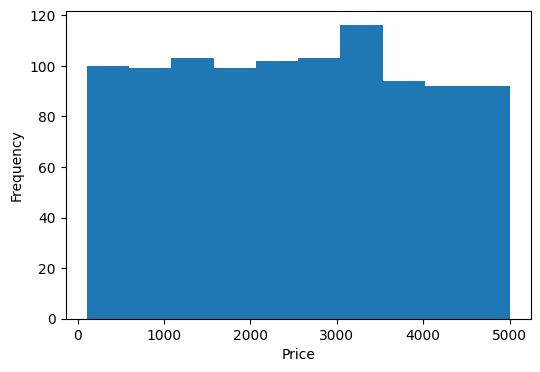

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df['Price'])
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

Average delivery duration?

In [10]:
print(df['Delivery_Days'].mean())

7.804


Average product price?

In [11]:
print(df['Price'].mean())

2532.7704900000003


Average customer rating?

In [13]:
print(df['Customer_Rating'].mean())

2.939


Phase 3: Return Pattern Investigation  
Category vs Return Rate

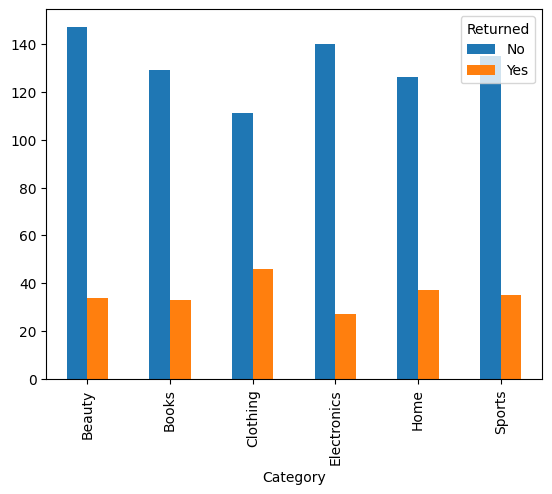

In [15]:
category_return = pd.crosstab(df['Category'],df['Returned'])

category_return.plot(kind='bar')
plt.show()

Price vs Return Rate

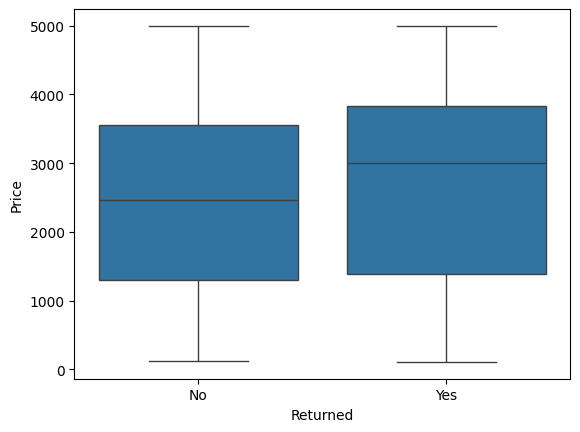

In [17]:
import seaborn as sns
sns.boxplot(x='Returned',y='Price',data=df)
plt.show()

Delivery Time vs Return Rate

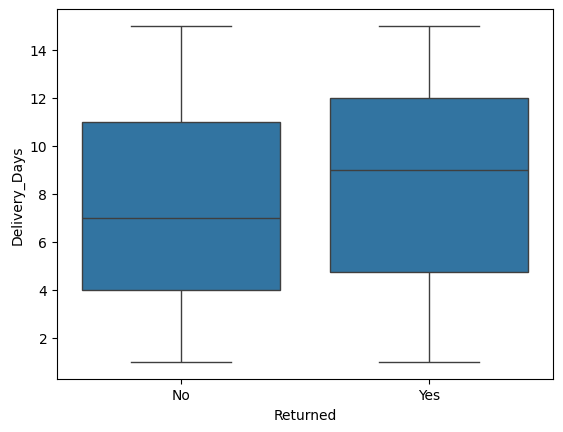

In [19]:
sns.boxplot(x='Returned',y='Delivery_Days',data=df)
plt.show()

Discounts vs Return Rate

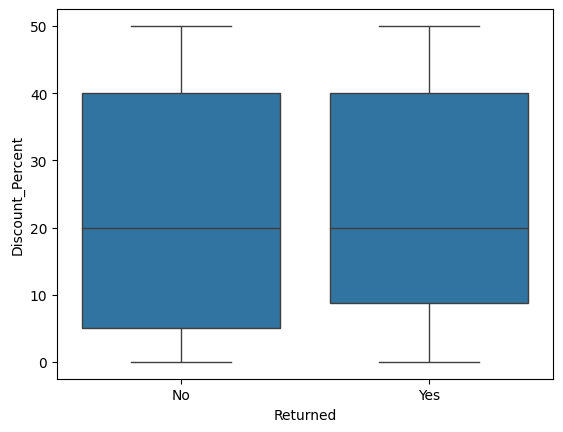

In [22]:
sns.boxplot(x='Returned',y='Discount_Percent',data=df)
plt.show()

Customer Rating vs Return Rate

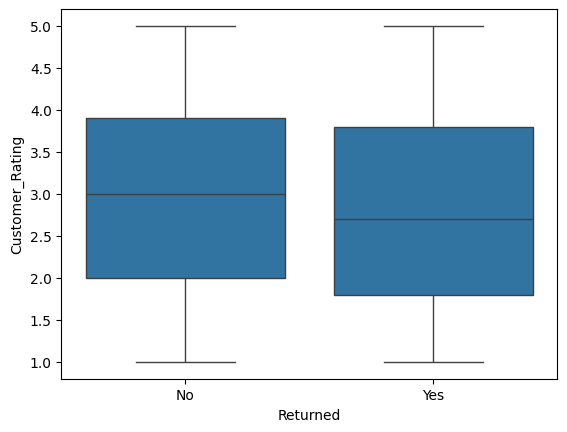

In [24]:
sns.boxplot(x='Returned',y='Customer_Rating',data=df)
plt.show()

Heatmap


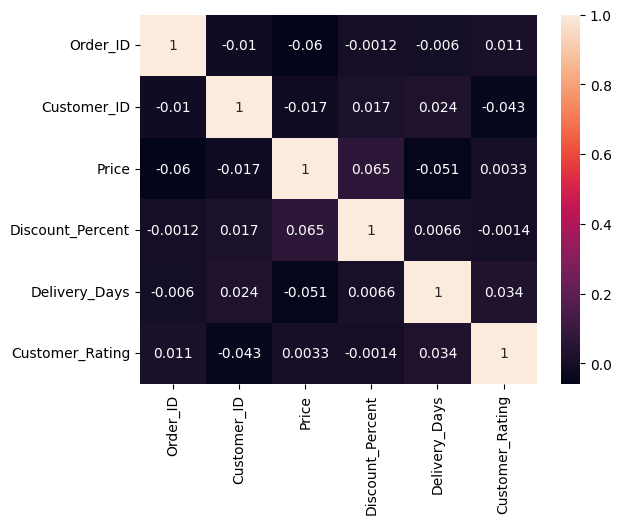

In [25]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

Which categories have highest return rates?

In [26]:
# Calculate return rate for each category
category_return_rate = (
    df.groupby('Category')['Returned']
      .apply(lambda x: (x == 'Yes').mean() * 100)
      .sort_values(ascending=False)
)

print(category_return_rate)

Category
Clothing       29.299363
Home           22.699387
Sports         20.588235
Books          20.370370
Beauty         18.784530
Electronics    16.167665
Name: Returned, dtype: float64


To visualize the results:

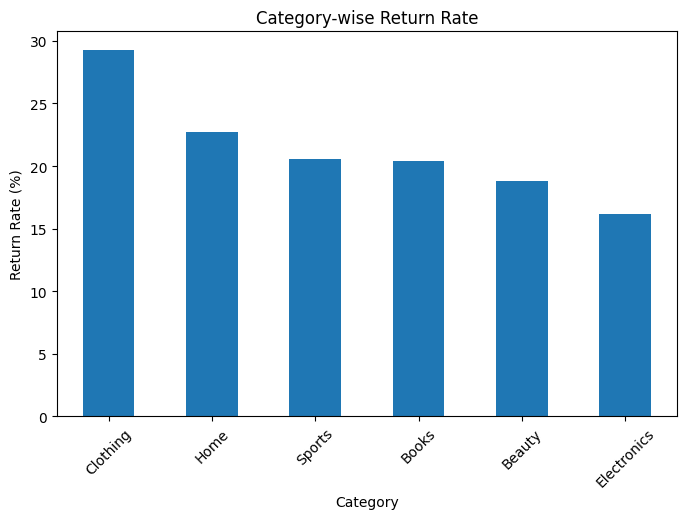

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
category_return_rate.plot(kind='bar')

plt.title("Category-wise Return Rate")
plt.xlabel("Category")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=45)

plt.show()

To display only the category with the highest return rate:

In [28]:
print("Highest Return Category:", category_return_rate.idxmax())
print("Return Rate: {:.2f}%".format(category_return_rate.max()))

Highest Return Category: Clothing
Return Rate: 29.30%


Does high discounting increase returns?

In [29]:
# Average discount by return status
discount_return = df.groupby('Returned')['Discount_Percent'].mean()

print(discount_return)

Returned
No     21.503807
Yes    22.948113
Name: Discount_Percent, dtype: float64


Visualize using a boxplot

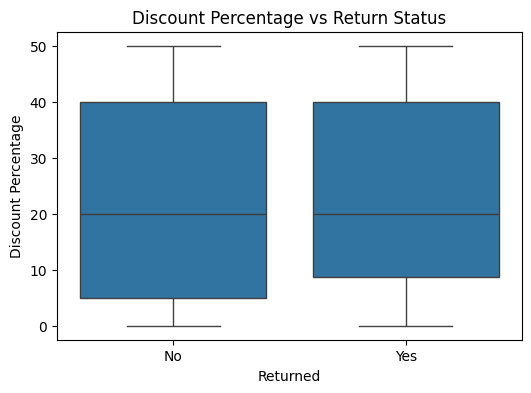

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.boxplot(x='Returned', y='Discount_Percent', data=df)

plt.title("Discount Percentage vs Return Status")
plt.xlabel("Returned")
plt.ylabel("Discount Percentage")
plt.show()

Phase 4: Outlier Analysis
Box plots

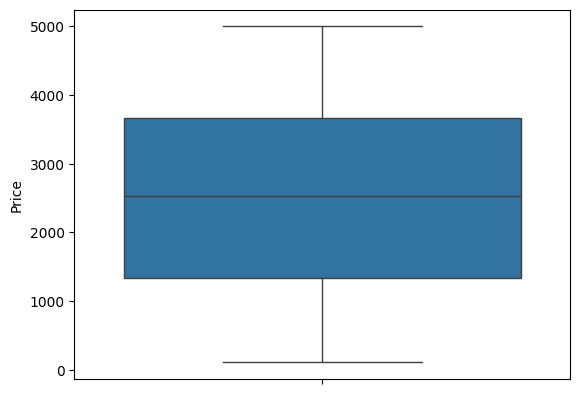

In [31]:
sns.boxplot(df['Price'])
plt.show()

IQR

In [32]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q3-Q1

lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

outliers = df[(df['Price']<lower)|(df['Price']>upper)]

outliers

,Order_ID,Customer_ID,Order_Date,Category,Price,Discount_Percent,Delivery_Days,Customer_Rating,Region,Returned


 Z-score

In [34]:
import numpy as np
from scipy import stats
z = np.abs(stats.zscore(df['Price']))

df[z>3]

,Order_ID,Customer_ID,Order_Date,Category,Price,Discount_Percent,Delivery_Days,Customer_Rating,Region,Returned


Phase 5: Hypothesis Testing
T-Test

In [36]:
from scipy import stats

returned = df[df['Returned']=='Yes']['Delivery_Days']
not_returned = df[df['Returned']=='No']['Delivery_Days']

t,p = stats.ttest_ind(returned,not_returned)

print(t)
print(p)

1.7624377759753513
0.07830142944766663


In [37]:
if p<0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Fail to Reject H0


Phase 6: Customer Segmentation

High Return Customers


In [39]:
customer_returns = df.groupby('Customer_ID')['Returned'].count()

customer_returns.sort_values(ascending=False)

,Returned
Customer_ID,
1273,8
1021,8
1046,8
1078,8
1251,8
...,...
1058,1
1068,1
1043,1


Premium Customers

In [40]:
premium = df[df['Price']>df['Price'].mean()]

premium.head()

,Order_ID,Customer_ID,Order_Date,Category,Price,Discount_Percent,Delivery_Days,Customer_Rating,Region,Returned
2,3,1142,02-01-2025,Books,3284.43,40,4,2.8,South,No
4,5,1235,18-05-2025,Home,4252.72,20,13,1.2,West,Yes
5,6,1035,12-01-2025,Electronics,2805.00,30,10,1.8,East,No
6,7,1186,11-02-2025,Electronics,4291.06,5,7,2.1,South,No
8,9,1028,28-02-2025,Home,4948.66,15,11,2.3,East,No


Discount Customers

In [43]:
discount = df[df['Discount_Percent']>df['Discount_Percent'].mean()]

In [46]:
display(discount.head())

,Order_ID,Customer_ID,Order_Date,Category,Price,Discount_Percent,Delivery_Days,Customer_Rating,Region,Returned
2,3,1142,02-01-2025,Books,3284.43,40,4,2.8,South,No
5,6,1035,12-01-2025,Electronics,2805.00,30,10,1.8,East,No
12,13,1195,02-06-2025,Books,883.91,40,10,1.3,East,No
18,19,1102,21-03-2025,Home,2685.60,40,4,4.7,East,No
19,20,1032,28-03-2025,Beauty,4508.11,50,2,2.0,South,Yes


Low Rating Customers

In [48]:
low_rating = df[df['Customer_Rating']<3]

In [49]:
display(low_rating.head())

,Order_ID,Customer_ID,Order_Date,Category,Price,Discount_Percent,Delivery_Days,Customer_Rating,Region,Returned
0,1,1052,23-06-2025,Books,645.52,20,4,1.9,North,No
1,2,1258,04-06-2025,Sports,2167.42,0,2,1.9,South,Yes
2,3,1142,02-01-2025,Books,3284.43,40,4,2.8,South,No
3,4,1172,27-01-2025,Books,2170.81,20,3,1.9,North,Yes
4,5,1235,18-05-2025,Home,4252.72,20,13,1.2,West,Yes
